# 🌸 L'Énigmatique Jardin d'Iris
## Classification des espèces d'Iris par apprentissage automatique

**Objectif** : Explorer, analyser et classifier les trois espèces d'iris (*Setosa*, *Versicolor*, *Virginica*) à partir de leurs mesures morphologiques.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

In [3]:
# Chargement du dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

In [4]:
print(X)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [5]:
# Creation d'un DataFrame pour une meilleure visualisation
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
print(df.head())
print(f'Dimensions : {df.shape}')
print(f'Espèces    : {list(iris.target_names)}')
print(f'Features   : {list(iris.feature_names)}')
df.head(10)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
Dimensions : (150, 5)
Espèces    : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Features   : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [6]:
df.dropna() 


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [7]:
# Vérification des valeurs manquantes
print('Valeurs manquantes par colonne :')
print(df.isnull().sum())

print('\nDistribution des espèces')
print(df['species'].value_counts())

Valeurs manquantes par colonne :
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Distribution des espèces
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [8]:
# Statistiques descriptives
print('Statistiques descriptives')
df.describe()

Statistiques descriptives


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
# Statistiques par espèce
df.groupby('species').describe()

sepal length (cm)                                              \
                       count   mean       std  min    25%  50%  75%  max   
species                                                                    
setosa                  50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8   
versicolor              50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0   
virginica               50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9   

           sepal width (cm)         ... petal length (cm)       \
                      count   mean  ...               75%  max   
species                             ...                          
setosa                 50.0  3.428  ...             1.575  1.9   
versicolor             50.0  2.770  ...             4.600  5.1   
virginica              50.0  2.974  ...             5.875  6.9   

           petal width (cm)                                            
                      count   mean       std  min  25%  50%  75%  max  
species                                                                
setosa                 50.0  0.246  0.105386  0.1  0.2  0.2  0.3  0.6  
versicolor             50.0  1.326  0.197753  1.0  1.2  1.3  1.5  1.8  
virginica              50.0  2.026  0.274650  1.4  1.8  2.0  2.3  2.5  

[3 rows x 32 columns]

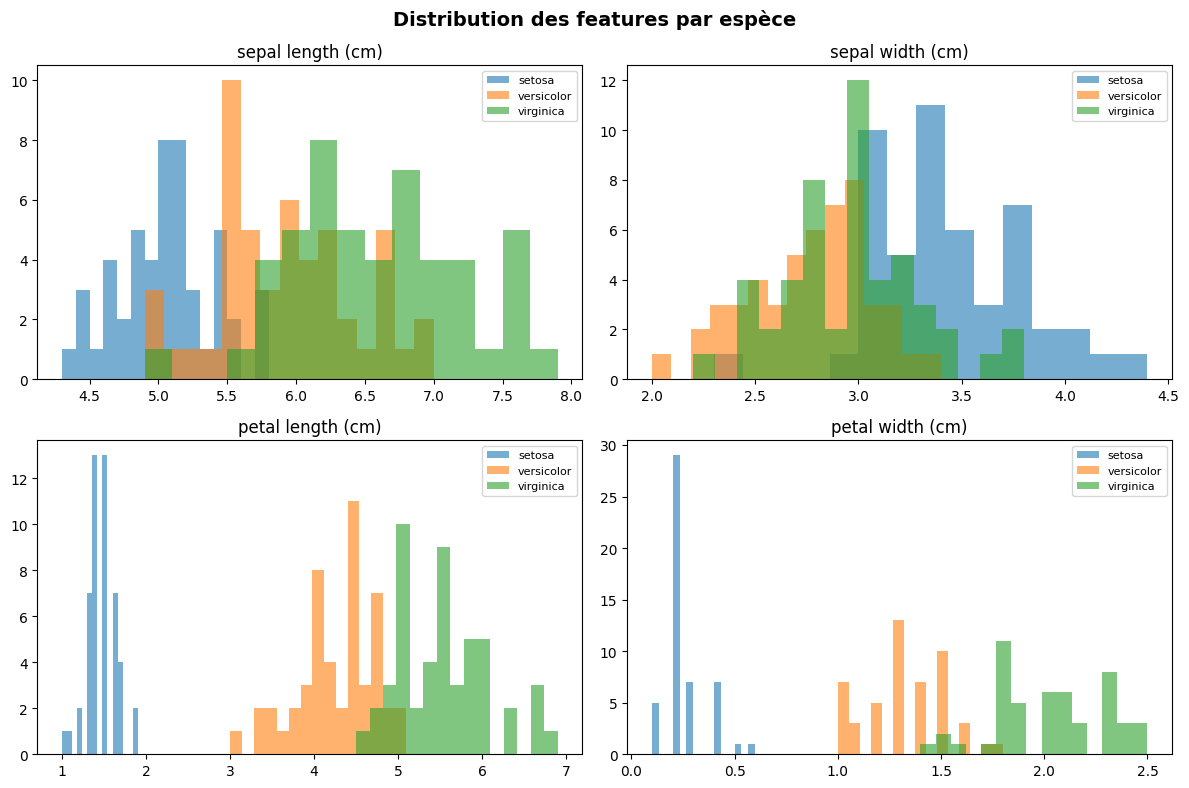

In [10]:
# Distribution de chaque feature par espèce
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = iris.feature_names

for ax, feat in zip(axes.flatten(), features):
    for species in iris.target_names:
        subset = df[df['species'] == species][feat]
        ax.hist(subset, alpha=0.6, label=species, bins=15)
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle('Distribution des features par espèce', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

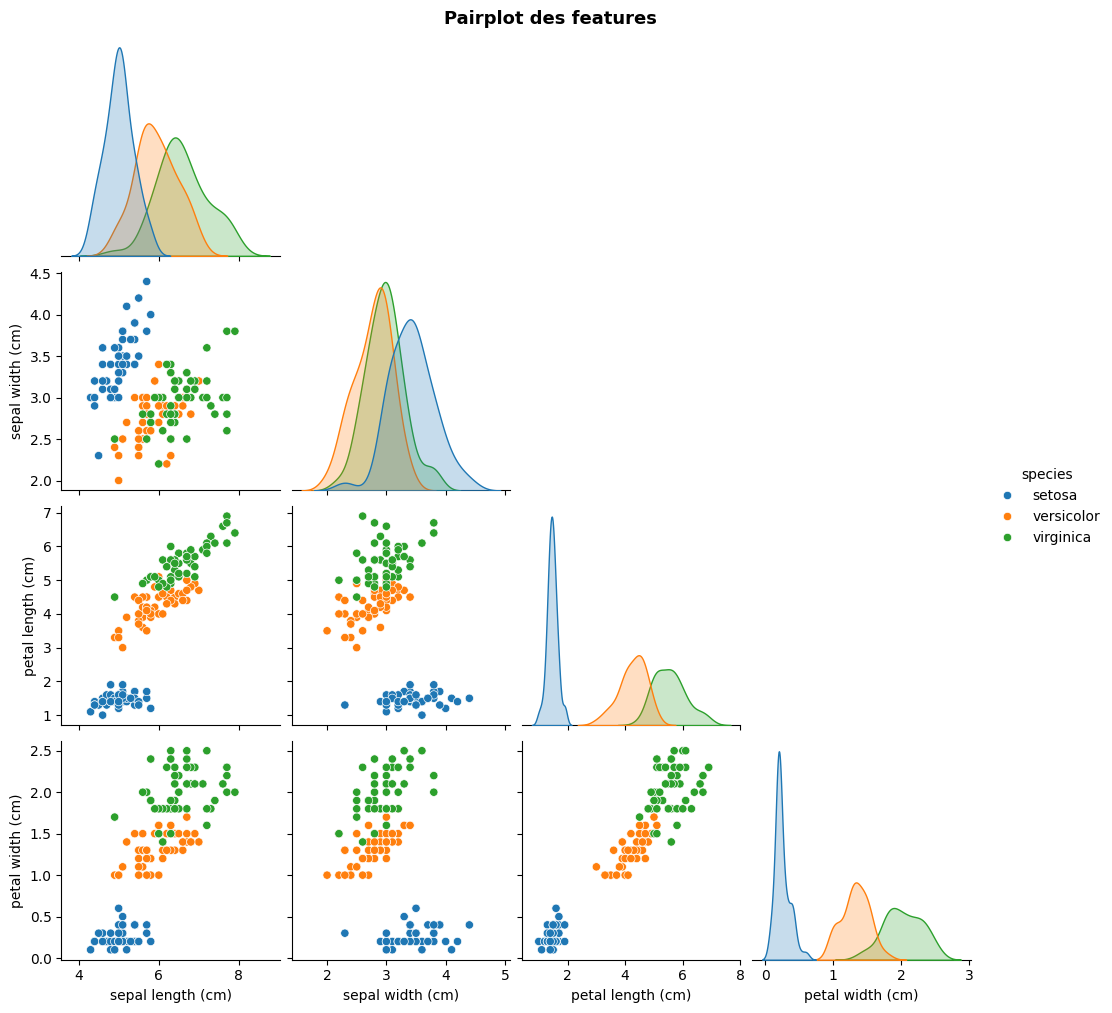

In [11]:
# Pairplot — relations entre toutes les features
sns.pairplot(df, hue='species', diag_kind='kde', corner=True)
plt.suptitle('Pairplot des features', y=1.01, fontsize=13, fontweight='bold')
plt.show()

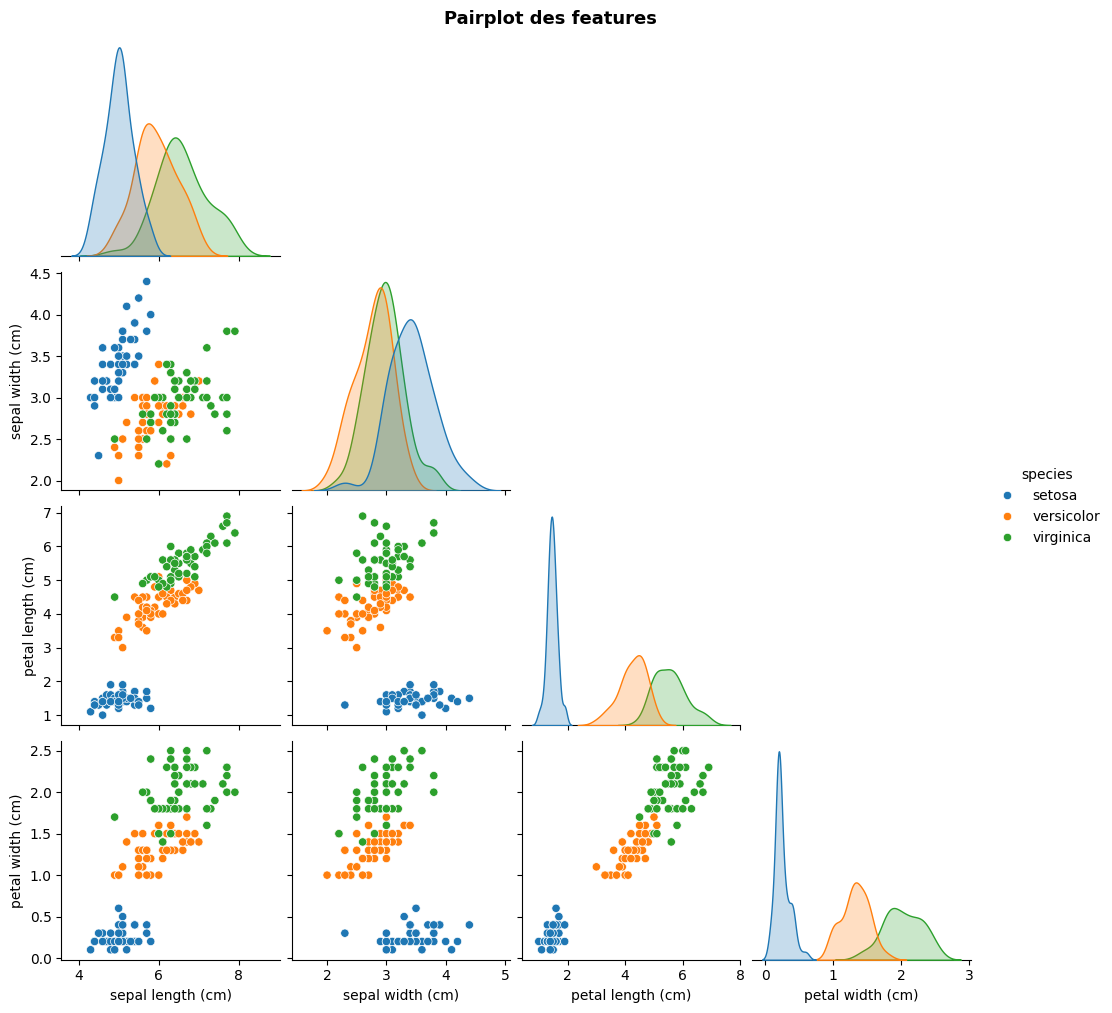

In [12]:
# Pairplot — relations entre toutes les features
sns.pairplot(df, hue='species', diag_kind='kde', corner=True)
plt.suptitle('Pairplot des features', y=1.01, fontsize=13, fontweight='bold')
plt.show()

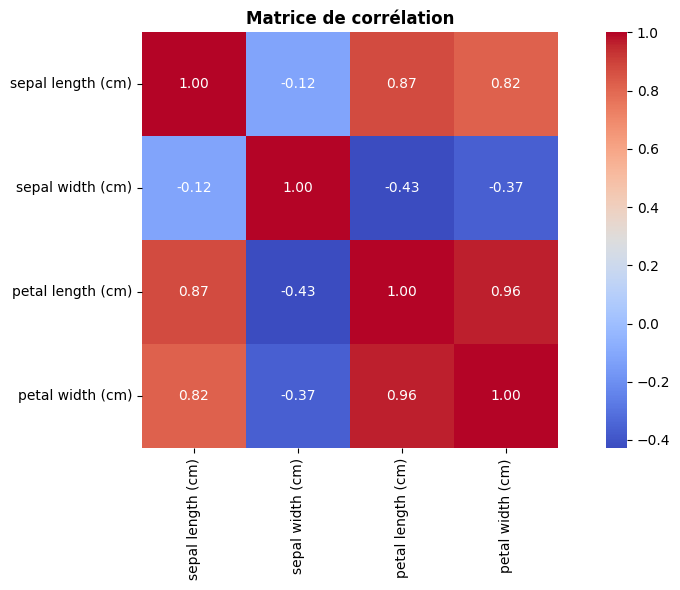

In [13]:
plt.figure(figsize=(10, 6))
corr = df.drop(columns='species').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matrice de corrélation', fontweight='bold')
plt.tight_layout()
plt.show() 

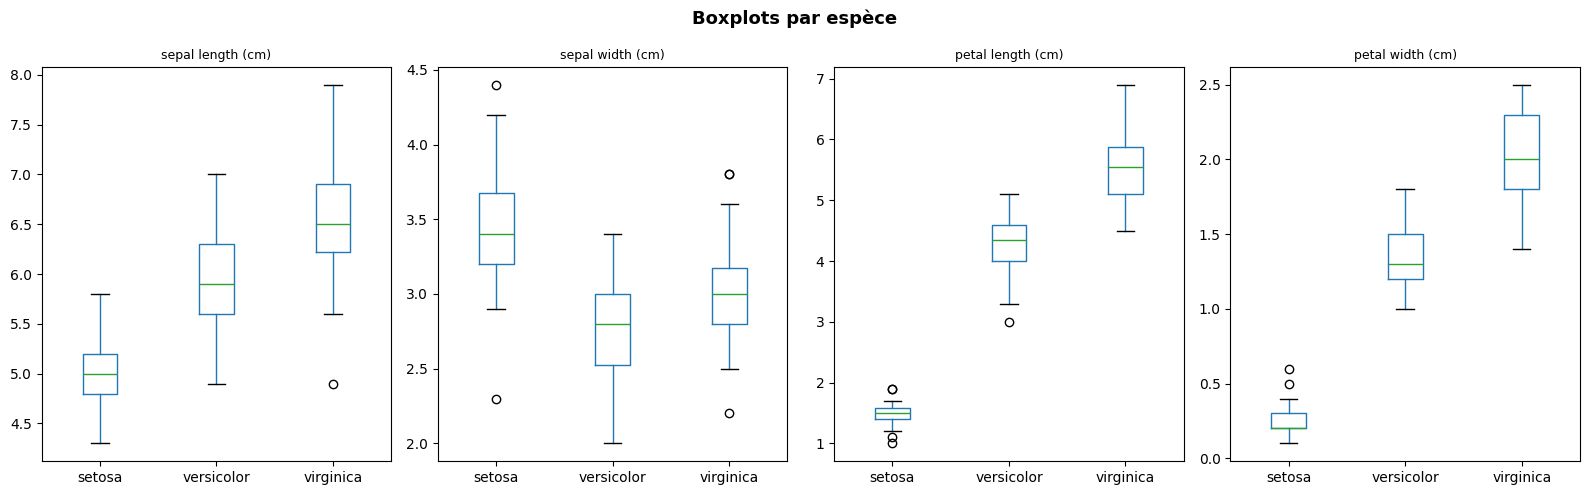

In [14]:
# Boxplots par espèce
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, feat in zip(axes, features):
    df.boxplot(column=feat, by='species', ax=ax, grid=False)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')

plt.suptitle('Boxplots par espèce', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Ingénierie des features (Feature Engineering)

In [18]:
# Création de features supplémentaires
df['sepal_ratio']  = df['sepal length (cm)'] / df['sepal width (cm)']
df['petal_ratio']  = df['petal length (cm)'] / df['petal width (cm)']
df['petal_area']   = df['petal length (cm)'] * df['petal width (cm)']   # approximation
df['sepal_area']   = df['sepal length (cm)'] * df['sepal width (cm)']

print('Features enrichies :')
print(df[['sepal_ratio','petal_ratio','petal_area','sepal_area']].describe())

Features enrichies :
       sepal_ratio  petal_ratio  petal_area  sepal_area
count   150.000000   150.000000  150.000000  150.000000
mean      1.953681     4.310500    5.794067   17.822867
std       0.400480     2.489648    4.712390    3.361854
min       1.268293     2.125000    0.110000   10.000000
25%       1.546188     2.802381    0.420000   15.660000
50%       2.032292     3.300000    5.615000   17.660000
75%       2.224910     4.666667    9.690000   20.325000
max       2.961538    15.000000   15.870000   30.020000


In [19]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

In [20]:
# Réduction de dimension : ACP (PCA) sur les 4 features originales
X_raw = iris.data
y = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f'Variance expliquée par PC1 + PC2 : {pca.explained_variance_ratio_.sum()*100:.1f}%')

Variance expliquée par PC1 + PC2 : 95.8%


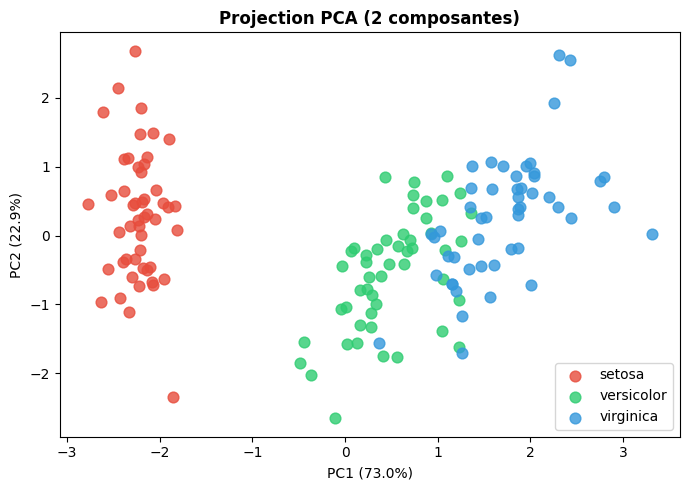

In [21]:
# Visualisation PCA
plt.figure(figsize=(7, 5))
colors = ['#e74c3c', '#2ecc71', '#3498db']
for i, sp in enumerate(iris.target_names):
    mask = y == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=sp, alpha=0.8, s=60, color=colors[i])

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Projection PCA (2 composantes)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()